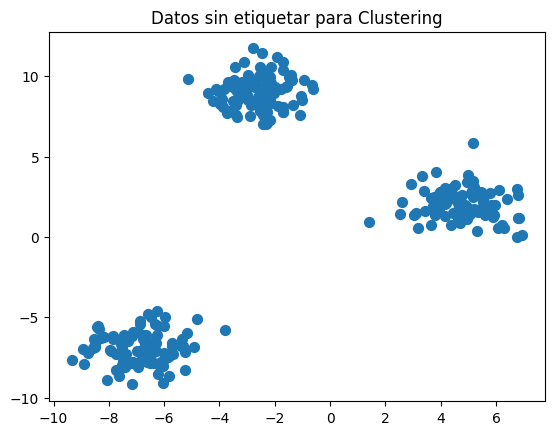

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar dataset sintético con 3 clusters
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Graficar los datos sin etiquetas
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Datos sin etiquetar para Clustering")
plt.show()

Ejercicio para la Sección 1
Objetivo: Comprender cómo se distribuyen los datos antes de aplicar clustering.

Instrucciones:

- Genera un dataset con 4 grupos utilizando make_blobs.
- Visualiza los datos en un gráfico de dispersión.
- Reflexiona sobre qué técnica de clustering sería la más adecuada para estos datos.

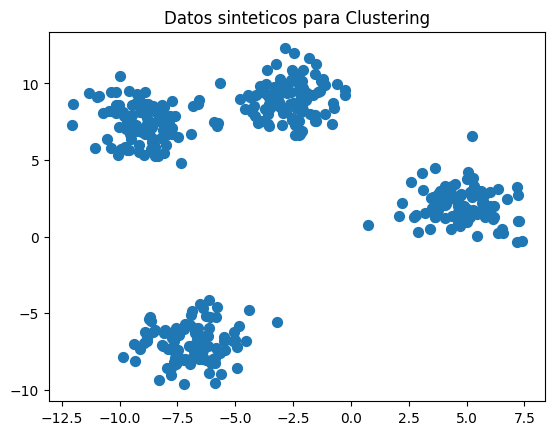

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Datos sinteticos para Clustering")
plt.show()

El proceso de K-Means sigue estos pasos:

- Seleccionar el número de clusters K.
- Inicializar los centroides de forma aleatoria.
- Asignar cada punto al centroide más cercano.
- Actualizar los centroides recalculando la media de cada cluster.
- Repetir los pasos 3 y 4 hasta que los centroides no cambien significativamente.


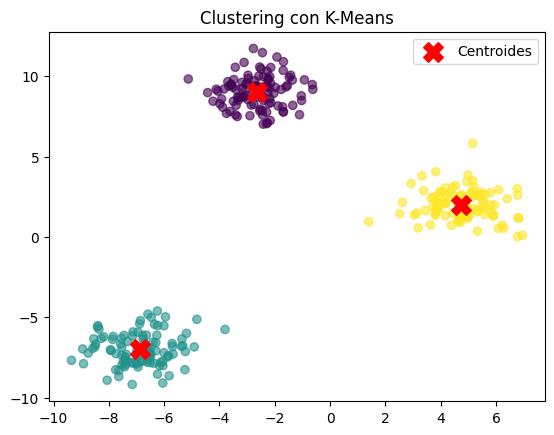

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generar datos sintéticos con 3 clusters
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Graficar clusters y centroides
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")
plt.title("Clustering con K-Means")
plt.legend()
plt.show()

Elección del Número de Clusters K
Uno de los desafíos de K-Means es elegir el número óptimo de clusters. Los principales métodos son:

- Método del Codo (Elbow Method): Calcula la suma de errores cuadrados para diferentes valores de K.
- Índice de Silhouette: Mide la cohesión y separación de los clusters.


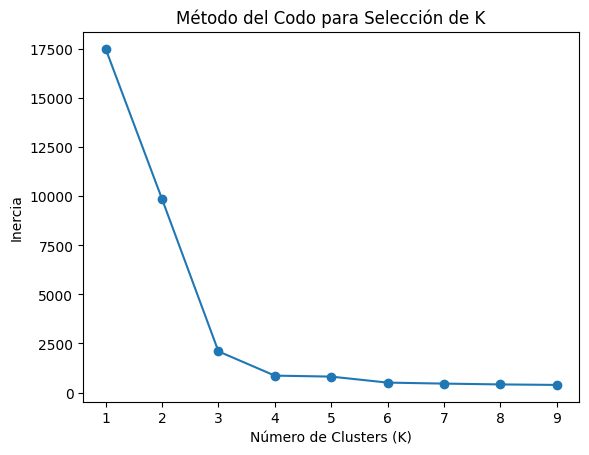

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generar datos
X, y = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)

# Calcular la inercia para diferentes valores de K
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

# Graficar el método del codo
plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Selección de K")
plt.show()

##### Conclusión: Se elige el punto donde la inercia deja de disminuir abruptamente, es decir, el "codo" de la curva.

Ejercicio para la Sección 2
Objetivo: Aplicar K-Means a un dataset real y determinar el número óptimo de clusters.

Instrucciones:

- Carga el dataset de pingüinos de Seaborn (sns.load_dataset("penguins")).
- Selecciona variables numéricas (ejemplo: bill_length_mm, bill_depth_mm).
- Usa el método del codo para determinar el mejor K.
- Aplica K-Means y visualiza los clusters.
- Explica qué insights puedes obtener de la segmentación.

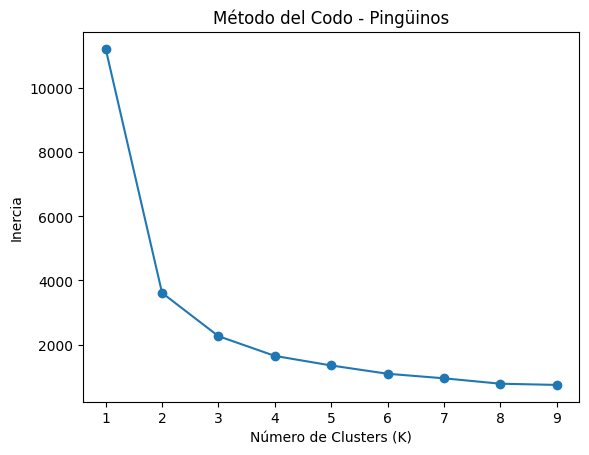

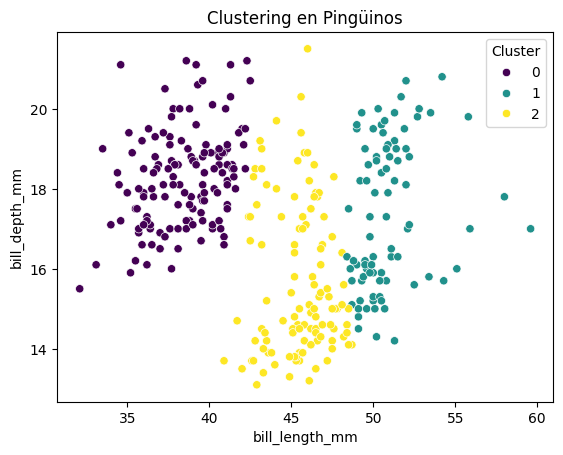

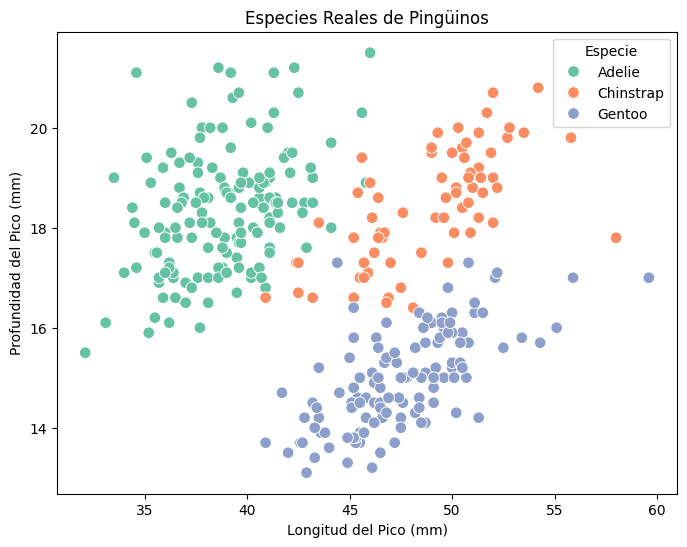

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Cargar dataset de pingüinos
df = sns.load_dataset("penguins").dropna()
X = df[["bill_length_mm", "bill_depth_mm"]]

# Método del Codo
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo - Pingüinos")
plt.show()

# Aplicar K-Means con K óptimo
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

sns.scatterplot(x=df["bill_length_mm"], y=df["bill_depth_mm"],
                hue=df["Cluster"], palette="viridis")
plt.title("Clustering en Pingüinos")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["bill_length_mm"], 
    y=df["bill_depth_mm"],
    hue=df["species"], 
    palette="Set2",
    s=70
)

plt.title("Especies Reales de Pingüinos")
plt.xlabel("Longitud del Pico (mm)")
plt.ylabel("Profundidad del Pico (mm)")
plt.legend(title="Especie")
plt.show()

2. Características de los Segmentos (Perfiles de los Clusters)El algoritmo divide la población de pingüinos en tres morfologías de pico muy claras:Cluster con picos cortos y profundos (Adelie): Se ubican arriba a la izquierda. Tienen una longitud de pico menor (generalmente $<42\text{ mm}$) pero son muy gruesos o profundos ($>17\text{ mm}$).Cluster con picos largos y delgados (Gentoo): Se ubican abajo a la derecha. Tienen picos notablemente más largos ($>45\text{ mm}$) pero perfiles mucho más estilizados y planos ($<16\text{ mm}$).Cluster con picos largos y profundos (Chinstrap): Se ubican arriba a la derecha. Combinan una gran longitud ($>45\text{ mm}$) con una gran profundidad ($>17\text{ mm}$).

###### 3.2. Funcionamiento del Algoritmo
- El algoritmo DBScan se basa en dos parámetros clave:

- ε (Epsilon): Determina la distancia máxima entre puntos vecinos.
minPts (Mínimo de puntos por cluster): Define cuántos puntos se requieren para formar un grupo denso.
Cómo funciona:

- Se selecciona un punto y se busca cuántos vecinos tiene en un radio ε.
Si hay al menos minPts vecinos, el punto se convierte en "punto núcleo" y se expande el cluster.
Si el punto tiene menos vecinos, se marca como "punto de ruido" (outlier).
Se repite hasta que todos los puntos han sido visitados.

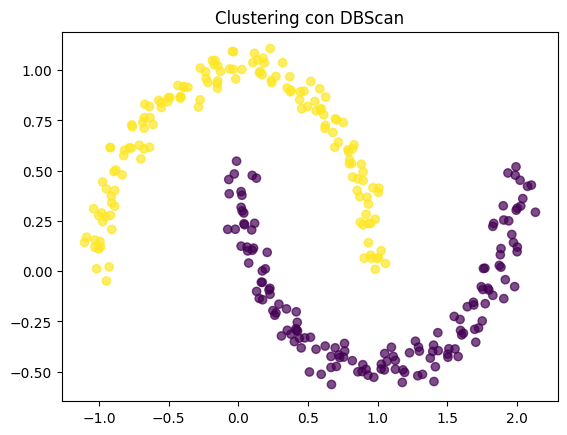

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generar datos con forma de media luna (difícil para K-Means)
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Aplicar DBScan
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(X)

# Visualizar resultados
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.title("Clustering con DBScan")
plt.show()


#### Ejercicio para la Sección 3
##### Objetivo: Aplicar DBScan a un dataset real y comparar los resultados con K-Means.

##### Instrucciones:

- Carga el dataset de flores Iris (sns.load_dataset("iris")).
- Selecciona dos características (sepal_length y sepal_width).
- Aplica DBScan y visualiza los clusters.
- Aplica K-Means y compara los resultados.
- Explica qué diferencias observas entre ambos métodos.

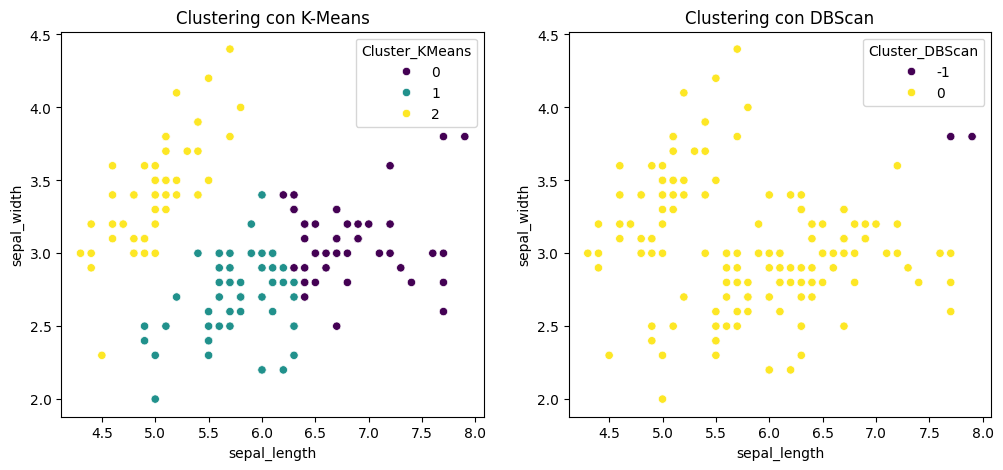

In [17]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# Cargar dataset Iris
df = sns.load_dataset("iris")
X = df[["sepal_length", "sepal_width"]].values

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X)

# Aplicar DBScan
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["Cluster_DBScan"] = dbscan.fit_predict(X)

# Visualizar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=df["Cluster_KMeans"], palette="viridis")
plt.title("Clustering con K-Means")

plt.subplot(1, 2, 2)
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=df["Cluster_DBScan"], palette="viridis")
plt.title("Clustering con DBScan")
plt.show()

Análisis de Diferencias Visuales y Mecánicas
Mecanismo de División: K-Means se ve obligado a romper el mapa de datos en 3 porciones geométricas rígidas (casi como rebanadas de pizza), buscando centros intermedios. DBSCAN, en cambio, busca "islas" densas de puntos separadas por zonas vacías o de baja densidad.

Forma del Grupo: K-Means traza fronteras lineales limpias entre clusters. DBSCAN sigue la silueta natural de la densidad, adaptándose a formas irregulares.

Respuestas a las Preguntas de Reflexión
1. ¿Cuántos clusters detectó DBSCAN en comparación con K-Means?
Mientras que a K-Means se le obligó por parámetro a buscar 3 clusters, DBSCAN detectó automáticamente 2 clusters principales (y un grupo extra de ruido).

El porqué biológico/matemático: En el dataset Iris, cuando mirás solo el sépalo (sepal_length y sepal_width), la especie Setosa forma un grupo densamente aislado y linealmente separable (Cluster 1). Sin embargo, las especies Versicolor y Virginica están completamente mezcladas y superpuestas en esa proyección. K-Means las corta a la mitad artificialmente para darte los 3 grupos que le pediste; DBSCAN entiende que matemáticamente son una sola gran masa densa y las agrupa juntas (Cluster 2).

2. ¿DBSCAN detectó puntos como outliers? ¿Por qué?
Sí. Vas a ver varios puntos pintados con un color asignado al valor -1 (generalmente en los extremos del gráfico o zonas aisladas).

Por qué ocurre: Por la definición del algoritmo. DBSCAN clasifica un punto como outlier (ruido) si no cumple con las condiciones de densidad: no tiene al menos min_samples=5 vecinos dentro de un radio de eps=0.5, ni tampoco es vecino cercano de un punto que sí cumpla esa condición. K-Means jamás detecta outliers; está obligado a asignar cada punto del mapa a un centroide, aunque esté a kilómetros de distancia.

3. ¿Qué ventajas ofrece DBSCAN en este caso?
No requiere adivinar: No tuviste que usar el Método del Codo ni saber de antemano que había 3 especies; el algoritmo decidió cuánta estructura real y densa había en los datos por sí mismo.

Limpieza de datos (Robustez): Al aislar los puntos periféricos como ruido (-1), evita que esos valores atípicos distorsionen y alteren la forma geométrica de las agrupaciones principales.

Fidelidad de la densidad: Refleja mejor la realidad de la distribución del sépalo. Te advierte visualmente que la frontera entre las otras dos especies no es clara en esas dimensiones, en lugar de mentirte con una división perfecta como hace K-Means.